In [8]:
# Cifar10 data loading and preprocessing
from matplotlib import table
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

#Transformations for data augmentation and normalization
transform = transforms.Compose([
    #transforms.RandomHorizontalFlip(), # Randomly flips the images to introduce variability
    #transforms.RandomCrop(32, padding=4), # Randomly crops the images to 32x32 with padding of 4 pixels
    # Blocking out above because apparently it causes images to become too chaotic in VAE training, run this through testing and see if it works
    transforms.ToTensor(), #Converts the images to PyTorch Tensors
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)) # Normalizes the images with mean and std deviation of 0.5 for each channel
])

# Transformations for validation set
transformVal = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
    # No random transformations for validation set
    # This ensures that the validation set is used as a representative sample of the data
])

# Donwload and load the CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train= True,
    download=True,
    transform=transform
)

# Donwload and load the CIFAR-10 dataset
val_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train= False,
    download=True,
    transform=transformVal
)

# Define batch size which can be adjusted based on how well the model trains and the available computational resources
batch_size = 128

# Create DataLoaders for training and validation datasets
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True, # Shuffling the training data to ensure that the model does not learn the order of the data and generalizes better
    num_workers=2  # Number of subprocesses to use for data loading. 0 means that the data will be loaded in the main process, which can be slower. Setting it to 2 allows for faster data loading by using two subprocesses.
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False, # No need to shuffle validation data as it is only used for evaluation
    num_workers=2 
)

print(f"Dataset: CIFAR-10")
print(f"Number of classes: 10")
print(f"Image size: 32x32 pixels")
print(f"Batch size: {batch_size}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Dataset: CIFAR-10
Number of classes: 10
Image size: 32x32 pixels
Batch size: 128
Training samples: 50000
Validation samples: 10000
Using device: cuda


In [9]:
# Creating VAE Model
import torch 
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()

        #Encoder 
        # Takes in a 3x32x32 image and compresses it to a latent representation of size latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1), # Output: 32x16x16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # Output: 64x8x8
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # Output: 128x4x4
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # Output: 256x2x2
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1), # Output: 512x1x1
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Flatten(), # Output: 512*1*1 = 512
        )

        # Mapping the flattened vector to the mean and log variance of the latent distribution
        self.fc_mu = nn.Linear(512, latent_dim) # Mean of the latent distribution
        self.fc_logvar = nn.Linear(512, latent_dim) # Log variance of the latent distribution

        # linear layer to expand latent vector before decoding
        self.decoder_input = nn.Linear(latent_dim, 512)

        #Decoder
        # Maps the latent vector back to the original image space
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1), # Output: 256x2x2
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # Output: 128x4x4
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # Output: 64x8x8
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # Output: 32x16x16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1), # Output: 3x32x32
            nn.BatchNorm2d(3),
            nn.Tanh(), # Output pixel values between -1 and 1
            # nn.Sigmoid() # Output pixel values between 0 and 1, but since we normalized the images to be between -1 and 1, we use tanh instead
        )
        """
            Ask Professor if its possible to use seperate data loaders for the GAN and VAR, 
            tanh is used more for GAN but sigmoid is more commonly used for VAE, but since we normalized the images to be between -1 and 1, we use tanh instead.
        """
    def encode(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x) # Get the mean of the latent distribution
        logvar = self.fc_logvar(x) # Get the log variance of the latent distribution
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        # using log variance to calculate the standard deviation
        std = torch.exp(0.5*logvar) # Standard deviation of the latent distribution
        eps = torch.randn_like(std) # Random noise sampled from a standard normal distribution
        return mu + eps*std # Reparameterization trick to sample from the latent distribution
    
    def decode(self, z):
        x = self.decoder_input(z)
        x = x.view(-1, 512, 1, 1) # Reshape to 512x1x1 to match the first ConvTranspose2d input
        x = self.decoder(x)
        return x
    
    def forward(self, x):
        mu, logvar = self.encode(x) # Encode the input image to get the mean and log variance of the latent distribution
        z = self.reparameterize(mu, logvar) # Sample from the latent distribution using the reparameterization trick
        reconstructed_x = self.decode(z) # Decode the sampled latent vector to get the reconstructed image
        return reconstructed_x, mu, logvar
    
# Instantiate the VAE model and move it to the appropriate device (GPU if available, otherwise CPU)
vae = VAE(latent_dim=128).to(device)
print(vae)

VAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): 

In [10]:
# Calculating the ELBO loss for the VAE
import torch.optim as optim
import torch.nn.functional as F

def elbo_loss(recon_x, x, mu, logvar, beta=0.1):
    # Calculate MSE per pixel, then sum across pixels, then mean across the batch
    recon_loss = F.mse_loss(recon_x, x, reduction='none')
    recon_loss = recon_loss.view(recon_x.size(0), -1).sum(dim=1).mean()

    # Sum KL divergence across latent dimensions, then mean across the batch
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()

    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
# model instance should already be created and moved earlier; ensure it's on correct device
vae = vae.to(device)

#Standard optimizer adam
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

epochs  = 80

# Cosine annealing scheduler: smoothly decays the learning rate from 1e-3 toward 0
# over the course of training, allowing finer weight updates in later epochs.
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

# KL annealing: beta linearly ramps from 0 to beta_max over the warmup period,
# letting the model learn good reconstructions before the KL term kicks in.
kl_warmup_epochs = 10
beta_max = 1.0

# Lists to store the average losses for each epoch
history_total_loss = []
history_recon_loss = []
history_kl_loss = []
history_val_loss = []
history_beta = []

import time
start_time = time.time()

print("Starting training...")

# Initialize best validation loss to infinity
best_val_loss = float('inf')

vae.train()
for epoch in range(epochs):
    # KL annealing: linearly increase beta from 0 to beta_max over the warmup period
    beta = min(beta_max, beta_max * (epoch / kl_warmup_epochs))
    history_beta.append(beta)

    train_loss = 0.0
    train_recon = 0.0
    train_kl = 0.0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device) # Move the input data to the same device as the model

        # Zero the gradients before backpropagation
        optimizer.zero_grad()

        # Complete the forward pass through the VAE model
        recon_batch, mu, logvar = vae(data)

        # Calculate the ELBO loss with current annealed beta
        loss, recon_loss, kl_loss = elbo_loss(recon_batch, data, mu, logvar, beta=beta)

        # Backpropagation and optimization step
        loss.backward()
        optimizer.step()

        # Accumulate the losses (divded by batch size to get the average loss per sample)
        train_loss += loss.item() / data.size(0)
        train_recon += recon_loss.item() / data.size(0)
        train_kl += kl_loss.item() / data.size(0)

    # Calculate the average losses for this current epoch
    avg_loss = train_loss/(len(train_loader.dataset))
    avg_recon = train_recon/(len(train_loader.dataset))
    avg_kl = train_kl/(len(train_loader.dataset))

    # Store the values for plotting later
    history_total_loss.append(avg_loss)
    history_recon_loss.append(avg_recon)
    history_kl_loss.append(avg_kl)

    vae.eval() # Set the model to evaluation mode for validation
    val_loss = 0.0

    #Disable gradient calculation for validation to save memory and computation
    with torch.no_grad():
        for data, _ in val_loader:
            data = data.to(device)
            recon_batch, mu, logvar = vae(data)
            loss, _, _ = elbo_loss(recon_batch, data, mu, logvar, beta=beta)
            val_loss += loss.item() / data.size(0)
    
    avg_val_loss = val_loss/(len(val_loader.dataset))
    history_val_loss.append(avg_val_loss)

    # Step the LR scheduler after each epoch
    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}] - Beta: {beta:.3f}, LR: {scheduler.get_last_lr()[0]:.6f}, Total Loss: {avg_loss:.4f}, Recon Loss: {avg_recon:.4f}, KL Loss: {avg_kl:.4f}, Val Loss: {avg_val_loss:.4f}")

    # save best model each epoch
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(vae.state_dict(), 'best_vae.pth') # Save the best model

vae.load_state_dict(torch.load('best_vae.pth')) # Load the best model after training is complete
end_time = time.time()
print(f"Training complete. Best model loaded.")
print(f"Total training time: {end_time - start_time:.2f} seconds")

total_params = sum(p.numel() for p in vae.parameters())
trainable_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Using device: cuda
Starting training...
Epoch [1/80] - Beta: 0.000, LR: 0.001000, Total Loss: 5.2968, Recon Loss: 5.2968, KL Loss: 1382530315185566464.0000, Val Loss: 5.9539
Epoch [2/80] - Beta: 0.100, LR: 0.000998, Total Loss: 3.6949, Recon Loss: 3.6230, KL Loss: 0.7194, Val Loss: 3.0971
Epoch [3/80] - Beta: 0.200, LR: 0.000997, Total Loss: 3.0883, Recon Loss: 3.0035, KL Loss: 0.4238, Val Loss: 3.0985
Epoch [4/80] - Beta: 0.300, LR: 0.000994, Total Loss: 3.0042, Recon Loss: 2.9095, KL Loss: 0.3155, Val Loss: 2.9309
Epoch [5/80] - Beta: 0.400, LR: 0.000990, Total Loss: 2.8533, Recon Loss: 2.7503, KL Loss: 0.2575, Val Loss: 2.8235
Epoch [6/80] - Beta: 0.500, LR: 0.000986, Total Loss: 2.6649, Recon Loss: 2.5369, KL Loss: 0.2560, Val Loss: 2.6751
Epoch [7/80] - Beta: 0.600, LR: 0.000981, Total Loss: 2.6338, Recon Loss: 2.5007, KL Loss: 0.2218, Val Loss: 2.6496
Epoch [8/80] - Beta: 0.700, LR: 0.000976, Total Loss: 2.5670, Recon Loss: 2.4182, KL Loss: 0.2126, Val Loss: 2.5225
Epoch [9/80] -

In [12]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


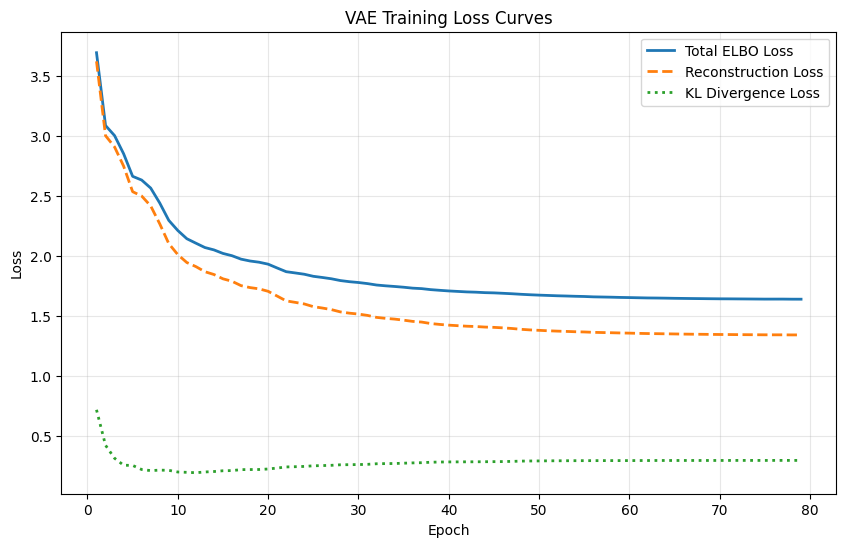

In [ ]:
# Plotting the training and validation losses
import matplotlib.pyplot as plt

# Create a figre for the loss curves
plt.figure(figsize=(10, 6))

# Plot the three loss components
#Not starting at epoch 1 because the first epoch can have a very high loss due to random initialization, which can skew the scale of the plot and make it harder to see the trends in the later epochs. By starting at epoch 1, we can focus on the more stable part of the training process and better visualize the loss curves as they evolve.
plt.plot(range(1, len(history_total_loss)), history_total_loss[1:],label='Total ELBO Loss', linewidth=2)
plt.plot(range(1, len(history_recon_loss)), history_recon_loss[1:],label='Reconstruction Loss', linewidth=2, linestyle='--')
plt.plot(range(1, len(history_kl_loss)), history_kl_loss[1:],label='KL Divergence Loss', linewidth=2, linestyle=':')

plt.title('VAE Training Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('vae_loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()


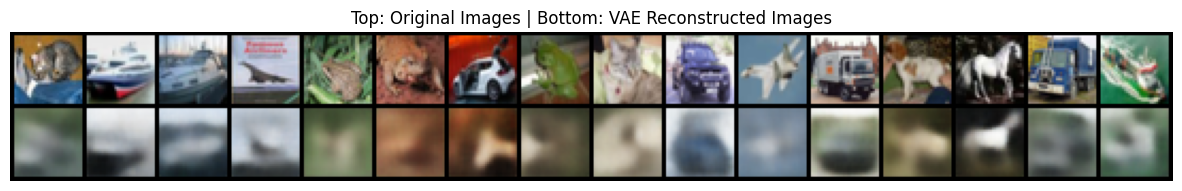

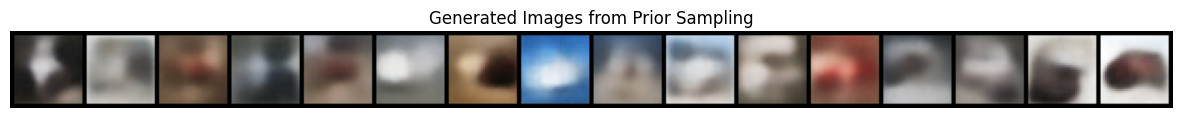

In [17]:
# Generating the 16 grid of images from the trained VAE model
from torch import tensor
import torchvision.utils as vutils

# Helper function to un-normalize the images for visualization
def unnormalize(img):
    return (img + 1) / 2.0 # Un-normalize the images from the range [-1, 1] back to [0, 1] for visualization

# Reconstructing images from the validation set to visualize the performance of the VAE
vae.eval() # Set the model to evaluation mode
# Grab a single batch of validation images
dataiter = iter(val_loader)
images, _ = next(dataiter)
images = images[:16].to(device) # Take the first 16 images from the batch and move them to the same device as the model

with torch.no_grad(): # Disable gradient calculation for inference
    recon_images, _, _ = vae(images) # Get the reconstructed images from the VAE

# Stack original and reconstructed images together for visualization
comparison = torch.cat([images, recon_images], dim=0)
# Create a grid of images and display it
comparison_grid = vutils.make_grid(unnormalize(comparison), nrow=16, padding=2)

plt.figure(figsize=(15, 4))
plt.imshow(comparison_grid.cpu().permute(1, 2, 0)) # Move the grid to CPU and permute dimensions for plotting
plt.title("Top: Original Images | Bottom: VAE Reconstructed Images")
plt.axis('off')
plt.savefig('vae_reconstructions.png', dpi=300, bbox_inches='tight')
plt.show()

# Prior sampling
# Sample random noise z ~ N(0, I) from the latent space and decode it to generate new images
z = torch.randn(16, 128).to(device) # Sample 16 random latent vectors from a standard normal distribution

with torch.no_grad():
    generated_images = vae.decode(z) # Decode the random latent vectors to generate new images

sample_grid = vutils.make_grid(unnormalize(generated_images), nrow=16, padding=2)
plt.figure(figsize=(15, 4))
plt.imshow(sample_grid.cpu().permute(1, 2, 0))
plt.title("Generated Images from Prior Sampling")
plt.axis('off')
plt.savefig('vae_generated_images.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# GAN parameters
nz = 100 # Size of z latent vector (i.e. size of the input)
ngf = 64 # Size of feature maps in the generator
ndf = 64 # Size of feature maps in the discriminator
nc = 3 # Number of channels in the training images (RGB)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define the Generator Network
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input is Z, going into a convolution
            nn.ConvTranspose2d(nz, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # State size. (ngf*4) x 4 x 4

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # State size. (ngf*2) x 8 x 8

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # State size. (ngf) x 16 x 16

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh() # Outputs images in the range [-1, 1]
            # State size. (nc) x 32 x 32
            
        )

    def forward(self, input):
        return self.main(input)

# Define the Discriminator Network
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input is (nc) x 32 x 32
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # State size. (ndf) x 16 x 16

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # State size. (ndf*2) x 8 x 8

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # State size. (ndf*4) x 4 x 4

            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid() # Outputs a single value between 0 and 1
        )

    def forward(self, input):
        return self.main(input).view(-1)


# Initialize the Generator and Discriminator
netG = Generator().to(device)
netD = Discriminator().to(device)

# Standard DCGAN weight initialization
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG.apply(weights_init)
netD.apply(weights_init)

print("DCGAN initialized")

Using device: cuda
DCGAN initialized


In [ ]:
import time
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
# Loss function 
criterion = nn.BCELoss()

# Add fixed noise to track progress
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Set up labeles for images
real_label = 1
fake_label = 0

# Setup Adam Optimizers for both the generator and discriminator
lr = 0.0002
beta1 = 0.5
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# Lists to track losses and for report
G_losses = []
D_losses = []

num_epochs = 50
print(f"Starting training for {num_epochs} epochs...")
start_time = time.time()

# Training loop
for epoch in range(num_epochs):
    for i, data in enumerate(train_loader, 0):
        # Update the discriminator
        netD.zero_grad()

        # Format batch of real images
        real_images = data[0].to(device)
        b_size = real_images.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)

        # Forward pass real batch throguh D
        output = netD(real_images)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        # Generate a batch of fake images
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(fake_label)

        # Classify fake batch with D
        output = netD(fake.detach()) # Prevents backprop to G
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()

        # COmpute error of D as sum of errors for real and fake batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        # Update G maximize log(D(G(z)))
        netG.zero_grad()
        label.fill_(real_label) # Fake label is real for generator update

        # Since we updated D, perform another forward pass of all-real batch through D
        output = netD(fake)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        # Save losses for plotting later    
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Print training stats
        print(f"[Epoch {epoch}/{num_epochs}] [Batch {i}/{len(train_loader)}] [D loss: {errD.item():.4f}] [G loss: {errG.item():.4f}]")
            

end_time = time.time()
print(f"Training complete. Best model loaded.")

total_params = sum(p.numel() for p in vae.parameters())
trainable_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
        


Starting training for 50 epochs...
[Epoch 0/50] [Batch 0/391] [D loss: 0.6283] [G loss: 3.2426]
[Epoch 0/50] [Batch 1/391] [D loss: 0.5860] [G loss: 3.2506]
[Epoch 0/50] [Batch 2/391] [D loss: 0.6424] [G loss: 3.2869]
[Epoch 0/50] [Batch 3/391] [D loss: 0.6627] [G loss: 3.4209]
[Epoch 0/50] [Batch 4/391] [D loss: 0.7670] [G loss: 3.4351]
[Epoch 0/50] [Batch 5/391] [D loss: 0.8978] [G loss: 3.5033]
[Epoch 0/50] [Batch 6/391] [D loss: 0.9625] [G loss: 3.6075]
[Epoch 0/50] [Batch 7/391] [D loss: 0.9764] [G loss: 3.7810]
[Epoch 0/50] [Batch 8/391] [D loss: 0.8719] [G loss: 3.9527]
[Epoch 0/50] [Batch 9/391] [D loss: 0.9198] [G loss: 4.1485]
[Epoch 0/50] [Batch 10/391] [D loss: 1.0303] [G loss: 4.2944]
[Epoch 0/50] [Batch 11/391] [D loss: 1.0693] [G loss: 4.2350]
[Epoch 0/50] [Batch 12/391] [D loss: 0.9543] [G loss: 4.1992]
[Epoch 0/50] [Batch 13/391] [D loss: 0.9479] [G loss: 4.4772]
[Epoch 0/50] [Batch 14/391] [D loss: 0.8935] [G loss: 4.6620]
[Epoch 0/50] [Batch 15/391] [D loss: 0.6289] 

NameError: name 'vae' is not defined

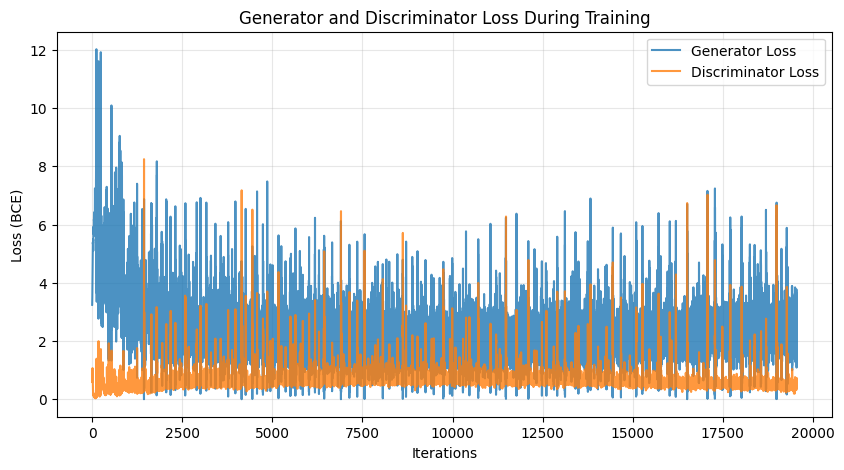

In [ ]:
# Plotting the loss curves
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
# Plotting the tracked losses
plt.plot(G_losses, label="Generator Loss", alpha=0.8)
plt.plot(D_losses, label="Discriminator Loss", alpha=0.8)
plt.xlabel("Iterations")
plt.ylabel("Loss (BCE)")
plt.legend()
plt.grid(True, alpha=0.3)

# Save before showing so that it doesn't get overwritten
plt.savefig('gan_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

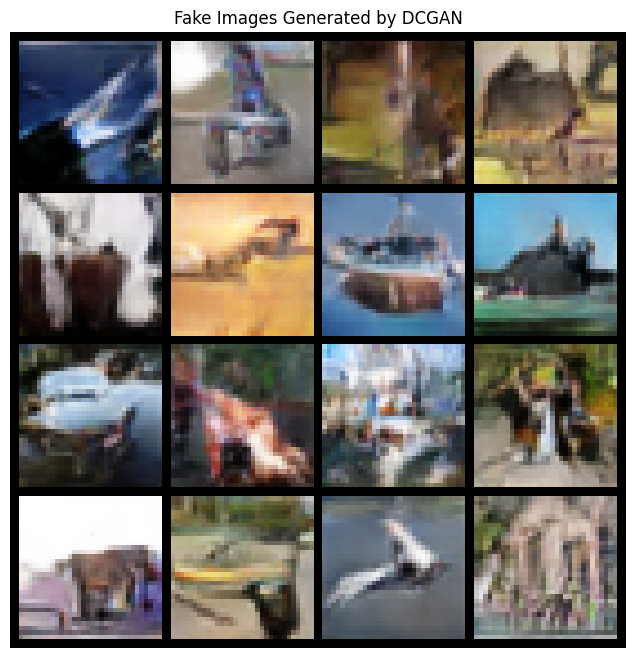

In [ ]:
# Generating fake images
import torchvision.utils as vutils

# Set generator to evaluation mode
netG.eval()

# Generate a batch of fake images using the fixed_noise we defined before training
with torch.no_grad():
    fake_images = netG(fixed_noise).detach().cpu()

# Un-normalize from [-1, 1] back to [0, 1] for matplotlib display
fake_images_unnorm = (fake_images + 1) / 2.0

# Create a grid of 16 images
fig = plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Fake Images Generated by DCGAN")
grid_img = vutils.make_grid(fake_images_unnorm[:16], padding=2, nrow=4)
plt.imshow(np.transpose(grid_img, (1, 2, 0)))

plt.savefig('gan_generated_grid.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
%pip install torchmetrics

   ---------------------------------------- 0.0/983.4 kB ? eta -:--:--
   ---------------------------------------- 983.4/983.4 kB 11.6 MB/s  0:00:00

   -------------------- ------------------- 1/2 [torchmetrics]
   -------------------- ------------------- 1/2 [torchmetrics]
   -------------------- ------------------- 1/2 [torchmetrics]
   -------------------- ------------------- 1/2 [torchmetrics]
   -------------------- ------------------- 1/2 [torchmetrics]
   ---------------------------------------- 2/2 [torchmetrics]

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Calculating the FID score
from torchmetrics.image.fid import FrechetInceptionDistance

# Initialize FID metric and move to GPU if available
fid = FrechetInceptionDistance(feature=64).to(device) 

print("Calculating FID... (This might take a minute)")

netG.eval()
with torch.no_grad():
    for i, (real_imgs, _) in enumerate(val_loader):
        real_imgs = real_imgs.to(device)
        
        # Convert real images from [-1, 1] float to [0, 255] uint8
        real_uint8 = ((real_imgs + 1) / 2.0 * 255).byte()
        fid.update(real_uint8, real=True)
        
        # Generate fake images to match the batch size
        noise = torch.randn(real_imgs.size(0), nz, 1, 1, device=device)
        fake_imgs = netG(noise)
        
        # Convert fake images from [-1, 1] float to [0, 255] uint8
        fake_uint8 = ((fake_imgs + 1) / 2.0 * 255).byte()
        fid.update(fake_uint8, real=False)

# Compute the final score
fid_score = fid.compute()
print(f"Fréchet Inception Distance (FID) on Validation Set: {fid_score.item():.4f}")

ModuleNotFoundError: FrechetInceptionDistance metric requires that `Torch-fidelity` is installed. Either install as `pip install torchmetrics[image]` or `pip install torch-fidelity`.